# pRSAc MCMC Fitting
**LLM 실험 데이터 → pRRSAc/pRRSAf 파라미터 추정**

```
Lumer semantics → L0 → U_epi, U_soc
                                ↓
LLM logit/choice data  →  PyMC MCMC
                                ↓
          φ_r, α_r, λ  추정  →  인간 비교
```

**pRRSAc 공식**:
$$U(u,s,r) = \phi_r\,U_{\text{epi}}(u,s) + (1-\phi_r)\,U_{\text{soc}}(u)$$
$$P_{S1}(u \mid s,r) \propto \exp(\lambda \cdot U(u,s,r))$$

**pRRSAf 공식**:
$$U(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

| 파라미터 | 의미 | 범위 |
|----------|------|------|
| `φ_r` | relationship별 epistemic 비중 (높을수록 솔직) | [0,1] |
| `α_r` | relationship별 social utility 가중치 (높을수록 face-saving) | [0,5] |
| `λ`   | rationality (높을수록 결정론적) | [0,20] |
| `c`   | LLM log-prob 절대값 오프셋 (RSA와의 스케일 차 보정) | ℝ |

**데이터 스케일 정리**:

| 모델 | 데이터 | 데이터 스케일 | RSA | Likelihood |
|------|--------|--------------|-----|------------|
| A | speaker_logit   | log P_LLM(u\|s,r) — 5개 내 정규화 | pRRSAc | Normal(log P_S1 + c, σ) |
| B | speaker_logit   | log P_LLM(u\|s,r) — 5개 내 정규화 | pRRSAf | Normal(log P_S1 + c, σ) |
| C | speaker_choice  | count(u\|s,r) | pRRSAc | Multinomial(P_S1) |
| D | speaker_choice  | count(u\|s,r) | pRRSAf | Multinomial(P_S1) |
| E | listener_logit  | log P_LLM(s\|u,r) — 5개 내 정규화 | pRRSAc | Normal(log P_L1 + c, σ) |
| F | listener_logit  | log P_LLM(s\|u,r) — 5개 내 정규화 | pRRSAf | Normal(log P_L1 + c, σ) |
| G | listener_choice | count(s\|u,r) | pRRSAc | Multinomial(P_L1) |
| H | listener_choice | count(s\|u,r) | pRRSAf | Multinomial(P_L1) |

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from pathlib import Path

from variables import ADJECTIVES, RELATIONSHIP_VAR, STATE_VAR

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# ── CONFIG ──────────────────────── (여기만 수정)
MODEL       = "llama3"   # "llama3" | "qwen3"
MCMC_DRAWS  = 2000
MCMC_TUNE   = 1000
MCMC_CHAINS = 4
# ────────────────────────────────────────────────

UTTERANCES  = ADJECTIVES
STATES      = STATE_VAR
RELATIONS   = RELATIONSHIP_VAR
N_utt  = len(UTTERANCES)
N_sta  = len(STATES)
N_rel  = len(RELATIONS)

print(f"모델   : {MODEL}")
print(f"발화   : {UTTERANCES}")
print(f"상태   : {STATES}")
print(f"관계   : {RELATIONS}")

모델   : llama3
발화   : ['großartig', 'gut', 'okay', 'schlecht', 'schrecklich']
상태   : [1, 2, 3, 4, 5]
관계   : ['Enge Freundin', 'Entfernte Kollegin', 'Lockere Chefin', 'Gefürchtete Chefin']


---
## Step 1 — Semantics & L0

`SEM[u, s]` = 발화 u가 상태 s에서 참말일 수 있다고 동의한 참가자 비율 (Lumer et al., Exp.1)

`L0[u, s]` = Literal Listener가 발화 u를 들었을 때 상태 s를 추론할 확률
$$P_{L_0}(s \mid u) \propto [\![u]\!](s) \cdot P(s) \quad \text{(uniform prior → 그냥 행 정규화)}$$

In [3]:
#                  s=1   s=2   s=3   s=4   s=5
SEM = np.array([
    [0.00, 0.03, 0.06, 0.16, 1.00],   # großartig
    [0.03, 0.03, 0.66, 1.00, 0.90],   # gut
    [0.06, 0.47, 1.00, 0.66, 0.47],   # okay
    [0.91, 0.59, 0.06, 0.00, 0.00],   # schlecht
    [0.84, 0.25, 0.00, 0.00, 0.00],   # schrecklich
], dtype=float)  # shape: (N_utt, N_sta)

# ── Smoothing: 0.00 → 0.01 ──────────────────────────────────────────────────
# 0이 있으면 L0=0 → log(0)=-∞ → RSA가 그 조합을 완전 배제
# LLM은 0%를 주지 않으므로, 최소 1% floor로 불일치 완화
SEM_RAW = SEM.copy()
SEM = np.maximum(SEM, 0.01)
print(f"Smoothing: {(SEM_RAW == 0).sum()}개 셀이 0.00 → 0.01로 변경")

# ── L0 계산 ─────────────────────────────────────────────────────────────────
# P(s) = uniform = 1/5 → 행 합산 후 정규화하면 prior 상수 사라짐
prior_s = np.ones(N_sta) / N_sta
L0 = SEM * prior_s[np.newaxis, :]          # (N_utt, N_sta)
L0 = L0 / L0.sum(axis=1, keepdims=True)   # 행 정규화
# L0[u, s] = P_L0(s | u)

print("\nL0 — P_L0(s | u):")
pd.DataFrame(L0, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3)

Smoothing: 6개 셀이 0.00 → 0.01로 변경

L0 — P_L0(s | u):


,s=1,s=2,s=3,s=4,s=5
großartig,0.008,0.024,0.048,0.127,0.794
gut,0.011,0.011,0.252,0.382,0.344
okay,0.023,0.177,0.376,0.248,0.177
schlecht,0.576,0.373,0.038,0.006,0.006
schrecklich,0.750,0.223,0.009,0.009,0.009


---
## Step 2 — Utilities

**Epistemic utility** — 발화 u가 상태 s를 얼마나 잘 전달하는가
$$U_{\text{epi}}(u,s) = \log P_{L_0}(s \mid u)$$

**Social utility** — 발화 u가 상대방을 얼마나 기분 좋게 하는가
$$U_{\text{soc}}(u) = \mathbb{E}_{L_0}[s \mid u] = \sum_{s'} P_{L_0}(s' \mid u) \cdot s'$$

> U_soc는 state-independent (utterance당 하나의 값)

In [4]:
state_vals = np.array(STATES, dtype=float)   # [1,2,3,4,5]

U_epi = np.log(L0 + 1e-10)                       # (N_utt, N_sta)
U_soc = (L0 * state_vals[np.newaxis, :]).sum(1)   # (N_utt,)

print("U_epi = log P_L0(s | u):")
print(pd.DataFrame(U_epi, index=UTTERANCES,
                   columns=[f"s={s}" for s in STATES]).round(3).to_string())

print("\nU_soc = E_L0[s | u]  (높을수록 긍정적 발화):")
for u, v in zip(UTTERANCES, U_soc):
    bar = '█' * int(v * 5)
    print(f"  {u:12s}: {v:.3f}  {bar}")

U_epi = log P_L0(s | u):
               s=1    s=2    s=3    s=4    s=5
großartig   -4.836 -3.738 -3.045 -2.064 -0.231
gut         -4.470 -4.470 -1.379 -0.963 -1.069
okay        -3.792 -1.733 -0.978 -1.394 -1.733
schlecht    -0.552 -0.985 -3.271 -5.063 -5.063
schrecklich -0.288 -1.500 -4.718 -4.718 -4.718

U_soc = E_L0[s | u]  (높을수록 긍정적 발화):
  großartig   : 4.675  ███████████████████████
  gut         : 4.034  ████████████████████
  okay        : 3.380  ████████████████
  schlecht    : 1.494  ███████
  schrecklich : 1.304  ██████


---
## Step 3 — Data Loading

In [5]:
def _parse_adj(text):
    text = str(text).lower()
    found = {a: m.start() for a in UTTERANCES
             if (m := re.search(rf"\b{a}\b", text))}
    return min(found, key=found.get) if found else None

def _parse_state(text):
    m = re.search(r"[1-5]", str(text))
    return int(m.group()) if m else None
def analyze_compliance(model):
    p = Path(f"results/listener_choice_{model}_{SHOT}.csv")
    df = pd.read_csv(p)
    df["inferred"] = df["response_text"].apply(_parse_state)
    
    total = len(df)
    n_fail = df["inferred"].isna().sum()
    n_success = total - n_fail
    
    print(f"\n=== {model} listener choice 준수율 ===")
    print(f"전체: {total}")
    print(f"성공: {n_success} ({100*n_success/total:.1f}%)")
    print(f"실패: {n_fail}  ({100*n_fail/total:.1f}%)")
    
    # 실패 케이스 샘플 확인
    print("\n실패 샘플 10개:")
    print(df[df["inferred"].isna()]["response_text"].head(10).tolist())
    
    # 관계별 준수율
    print("\n관계별 준수율:")
    for rel in df["relationship"].unique():
        mask = df["relationship"] == rel
        sub = df[mask]
        fail = sub["inferred"].isna().sum()
        print(f"  {rel}: {100*(1-fail/len(sub)):.1f}%")
    
    # 발화별 준수율
    print("\n발화별 준수율:")
    for adj in df["adjective"].unique():
        mask = df["adjective"] == adj
        sub = df[mask]
        fail = sub["inferred"].isna().sum()
        print(f"  {adj}: {100*(1-fail/len(sub)):.1f}%")



# ─────────────────────────────────────────────────────────────────────────────
# [NOTE] scoring.py의 score_candidates() 처리 방식
#
#   ① Logit 정규화:
#      vocab 전체의 raw logit 중 5개 후보만 추출 →
#      그 5개 내에서 log-softmax 정규화 → logprob_{k} 저장
#      → speaker든 listener든 동일하게 "5개 내 renormalized log-prob"
#
#      speaker logprob_: log P_LLM(u|s,r)  ≈ log P_S1(u|s,r) 스케일
#      listener logprob_: log P_LLM(s|u,r) ≈ log P_L1(s|u,r) 스케일
#      → Normal likelihood: Normal(log P_RSA + c, σ)  (λ·U 아님!)
#
#   ② Listener logit 추출:
#      후보 = {" 1", " 2", " 3", " 4", " 5"} (단일 숫자 토큰)
#      → chain-rule 불필요, next-token logit 직접 추출 후 5개 내 정규화
#
#   ③ 시나리오 처리:
#      Logit 데이터는 평균 내면 안 됨 (로그 스케일 산술평균 ≠ 확률평균)
#      → flat_*_logit: 각 CSV 행을 독립 관측치로 처리
#      → φ_r/α_r은 likelihood 내에서 시나리오 전반 공유 파라미터로 추정
#      → load_speaker_logit: sanity check·PPC 전용 (모델 피팅 사용 X)
# ─────────────────────────────────────────────────────────────────────────────

# ── Choice 데이터 (시나리오 합산 → Multinomial) ───────────────────────────────

def load_speaker_counts(model):
    """counts_speaker[r, s, u] — situation+rep 합산, shape (N_rel, N_sta, N_utt)"""
    p = Path(f"results/speaker_choice_{model}.csv")
    if not p.exists(): return print(f"[없음] {p}")
    df = pd.read_csv(p)
    df["utterance"] = df["response_text"].apply(_parse_adj)
    n_fail = df["utterance"].isna().sum()
    print(f"파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)")
    df = df.dropna(subset=["utterance"])
    out = np.zeros((N_rel, N_sta, N_utt))
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES):
            mask = (df["relationship"] == rel) & (df["state"] == sta)
            for u_i, adj in enumerate(UTTERANCES):
                out[r_i, s_i, u_i] = (df.loc[mask, "utterance"] == adj).sum()
    print(f"speaker_counts_{model}: {out.shape}, total={out.sum():.0f}")
    return out


def load_listener_counts(model):
    """counts_listener[r, u, s] — situation+rep 합산, shape (N_rel, N_utt, N_sta)"""
    p = Path(f"results/listener_choice_{model}.csv")
    if not p.exists(): return print(f"[없음] {p}")
    df = pd.read_csv(p)
    df["inferred"] = df["response_text"].apply(_parse_state)
    n_fail = df["inferred"].isna().sum()
    print(f"파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)")
    df = df.dropna(subset=["inferred"])
    df["inferred"] = df["inferred"].astype(int)
    out = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            mask = (df["relationship"] == rel) & (df["adjective"] == adj)
            for s_i, sta in enumerate(STATES):
                out[r_i, u_i, s_i] = (df.loc[mask, "inferred"] == sta).sum()
    print(f"listener_counts_{model}: {out.shape}, total={out.sum():.0f}")
    return out


# ── Logit 데이터 — flat (시나리오 평균 X, 모델 A/B/E/F용) ────────────────────

def flat_speaker_logit(model):
    """
    각 CSV 행(situation × rep) × 5형용사 = 독립 관측치
    반환: (rel_idx, sta_idx, utt_idx, obs)
           log_S1[rel_idx, utt_idx, sta_idx] 인덱싱과 대응
    """
    p = Path(f"results/speaker_logit_{model}.csv")
    if not p.exists():
        print(f"[없음] {p}"); return None
    df = pd.read_csv(p)
    rows = []
    for _, row in df.iterrows():
        try:
            r_i = RELATIONS.index(row["relationship"])
            s_i = STATES.index(int(row["state"]))
        except ValueError:
            continue
        for u_i, adj in enumerate(UTTERANCES):
            col = f"logprob_{adj}"
            if col not in df.columns: continue
            rows.append({"rel_idx": r_i, "sta_idx": s_i,
                         "utt_idx": u_i, "obs": float(row[col])})
    df_f = pd.DataFrame(rows)
    n_cond = N_rel * N_sta * N_utt
    print(f"flat_speaker_logit_{model}: {len(df_f)} obs "
          f"({len(df_f)//n_cond} per condition × {n_cond} conditions)")
    return (df_f["rel_idx"].values.astype(int),
            df_f["sta_idx"].values.astype(int),
            df_f["utt_idx"].values.astype(int),
            df_f["obs"].values)


def flat_listener_logit(model):
    """
    각 CSV 행(situation × rep) × 5상태 = 독립 관측치
    반환: (rel_idx, utt_idx, sta_idx, obs)
           log_L1[rel_idx, utt_idx, sta_idx] 인덱싱과 대응
    """
    p = Path(f"results/listener_logit_{model}.csv")
    if not p.exists():
        print(f"[없음] {p}"); return None
    df = pd.read_csv(p)
    rows = []
    for _, row in df.iterrows():
        try:
            r_i = RELATIONS.index(row["relationship"])
            u_i = UTTERANCES.index(row["adjective"])
        except ValueError:
            continue
        for s_i, sta in enumerate(STATES):
            col = f"logprob_{sta}"
            if col not in df.columns: continue
            rows.append({"rel_idx": r_i, "utt_idx": u_i,
                         "sta_idx": s_i, "obs": float(row[col])})
    df_f = pd.DataFrame(rows)
    n_cond = N_rel * N_utt * N_sta
    print(f"flat_listener_logit_{model}: {len(df_f)} obs "
          f"({len(df_f)//n_cond} per condition × {n_cond} conditions)")
    return (df_f["rel_idx"].values.astype(int),
            df_f["utt_idx"].values.astype(int),
            df_f["sta_idx"].values.astype(int),
            df_f["obs"].values)


# ── Logit 데이터 — 시나리오 평균 (sanity check·PPC 전용) ─────────────────────

def load_speaker_logit(model):
    """[sanity/PPC 전용] logprobs_speaker[r, s, u] — situation 평균"""
    p = Path(f"results/speaker_logit_{model}.csv")
    if not p.exists(): return print(f"[없음] {p}")
    df = pd.read_csv(p)
    out = np.zeros((N_rel, N_sta, N_utt))
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES):
            mask = (df["relationship"] == rel) & (df["state"] == sta)
            for u_i, adj in enumerate(UTTERANCES):
                out[r_i, s_i, u_i] = df.loc[mask, f"logprob_{adj}"].mean()
    print(f"load_speaker_logit_{model}: {out.shape}  ※ sanity/PPC 전용")
    return out

In [6]:
analyze_compliance("qwen3")
analyze_compliance("llama3")

# ── Choice 데이터: 시나리오 합산 (Multinomial 모델 C/D/G/H용) ──────────────────
counts_speaker  = load_speaker_counts(MODEL)   # (N_rel, N_sta, N_utt) | None
counts_listener = load_listener_counts(MODEL)  # (N_rel, N_utt, N_sta) | None

# ── Logit 데이터: 시나리오 평균 없이 flat (Normal 모델 A/B/E/F용) ──────────────
flat_sp = flat_speaker_logit(MODEL)   # (u_epi, u_soc, obs, rel_idx) | None
flat_li = flat_listener_logit(MODEL)  # (rel_idx, utt_idx, sta_idx, obs) | None

# ── Logit 데이터: 시나리오 평균 (sanity check·PPC 전용) ────────────────────────
logprobs_speaker = load_speaker_logit(MODEL)   # (N_rel, N_sta, N_utt) | None

파싱 실패: 0/1000 (0.0%)
speaker_counts_llama3: (4, 5, 5), total=1000
[없음] results/listener_choice_llama3.csv
flat_speaker_logit_llama3: 500 obs (5 per condition × 100 conditions)
flat_listener_logit_llama3: 500 obs (5 per condition × 100 conditions)
load_speaker_logit_llama3: (4, 5, 5)  ※ sanity/PPC 전용


---
## Step 4 — Sanity Check (Numpy RSA)

PyMC 돌리기 전에 — 특정 파라미터 값에서 RSA 예측이 LLM 데이터와 얼마나 겹치는지 확인

In [7]:
def rsa_speaker(s_idx: int, phi: float, lam: float = 1.0) -> np.ndarray:
    """
    pRRSAc 화자 분포 (numpy 버전, 산티 체크용)

    U(u,s,r) = φ · U_epi(u,s) + (1-φ) · U_soc(u)
    P_S1(u|s,r) ∝ exp(λ · U)

    φ 해석:
      φ=1 → pure epistemic (완전 솔직)
      φ=0 → pure social    (완전 face-saving)
      인간 추정치: 0.22~0.45 (Lumer Table 4)
        → 낮을수록 그 관계에서 더 polite (Gefürchtete Chefin=0.22: 가장 face-saving)

    Parameters
    ----------
    s_idx : 상태 인덱스 (0~4)
    phi   : epistemic 비중 [0,1]
    lam   : rationality λ
    """
    u_e = U_epi[:, s_idx]                       # (N_utt,)
    u_s = U_soc                                  # (N_utt,)
    utility = phi * u_e + (1 - phi) * u_s
    logits  = lam * utility
    logits -= logits.max()                       # numerically stable
    probs   = np.exp(logits)
    return probs / probs.sum()


# ── 빠른 확인: phi=0.8, lam=1.5 ──────────────────────────────────────────────
print("phi=0.8, lam=1.5 일 때 P_S1(u | s):")
df_test = pd.DataFrame(
    {f"s={s}": rsa_speaker(i, phi=0.8, lam=1.5) for i, s in enumerate(STATES)},
    index=UTTERANCES,
).round(3)
print(df_test.to_string())

phi=0.8, lam=1.5 일 때 P_S1(u | s):
               s=1    s=2    s=3    s=4    s=5
großartig    0.006  0.041  0.064  0.178  0.706
gut          0.008  0.014  0.392  0.549  0.213
okay         0.015  0.305  0.521  0.269  0.079
schlecht     0.422  0.425  0.019  0.002  0.001
schrecklich  0.548  0.216  0.003  0.003  0.001


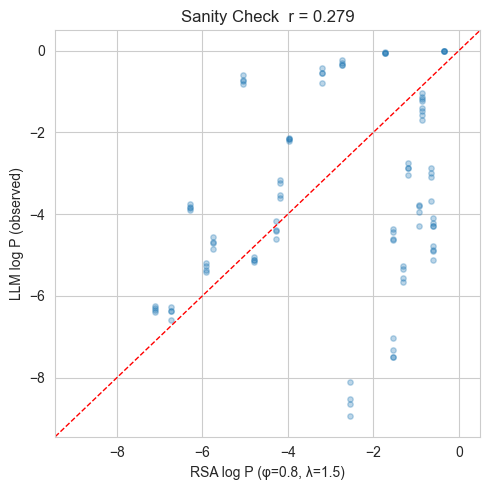

In [8]:
# ── Sanity plot: RSA 예측 vs LLM 관찰값 ──────────────────────────────────────
if logprobs_speaker is None:
    print("[skip] speaker_logit 데이터 없음")
else:
    utt_to_idx   = {u: i for i, u in enumerate(UTTERANCES)}
    state_to_idx = {s: i for i, s in enumerate(STATES)}

    phi_test, lam_test = 0.8, 1.5
    rsa_lp, llm_lp = [], []

    for r_i in range(N_rel):
        for s_i, sta in enumerate(STATES):
            probs = rsa_speaker(s_i, phi=phi_test, lam=lam_test)
            for u_i in range(N_utt):
                rsa_lp.append(np.log(probs[u_i] + 1e-10))
                llm_lp.append(logprobs_speaker[r_i, s_i, u_i])

    rsa_lp = np.array(rsa_lp)
    llm_lp = np.array(llm_lp)
    r = np.corrcoef(rsa_lp, llm_lp)[0, 1]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rsa_lp, llm_lp, alpha=0.3, s=15)
    lim = [min(rsa_lp.min(), llm_lp.min()) - 0.5,
           max(rsa_lp.max(), llm_lp.max()) + 0.5]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"RSA log P (φ={phi_test}, λ={lam_test})")
    ax.set_ylabel("LLM log P (observed)")
    ax.set_title(f"Sanity Check  r = {r:.3f}")
    plt.tight_layout()
    plt.savefig(f"results/plot_sanity_{MODEL}.png", dpi=150)
    plt.show()

---
## Step 5 — PyMC Forward Model (텐서 버전)

Multinomial 모델(C/D/E)에서 사용하는 pytensor 버전

In [9]:
def build_rsa(phi, lam):
    """
    pRRSAc: U = φ·U_epi + (1-φ)·U_soc

    phi : (N_rel,)  epistemic 비중 [0,1]
    lam : scalar    rationality λ
    → log_S1, log_L1 : (N_rel, N_utt, N_sta)
    """
    L0_t    = pt.as_tensor_variable(L0)
    U_epi_t = pt.as_tensor_variable(U_epi)
    s_t     = pt.as_tensor_variable(state_vals)
    U_soc_t = pt.dot(L0_t, s_t)                           # (N_utt,)

    phi_b   = phi[:, None, None]
    U = phi_b * U_epi_t[None,:,:] + (1-phi_b) * U_soc_t[None,:,None]

    logits_S1 = lam * U
    log_S1 = logits_S1 - pt.logsumexp(logits_S1, axis=1, keepdims=True)
    log_L1 = log_S1   - pt.logsumexp(log_S1,     axis=2, keepdims=True)
    return log_S1, log_L1


def build_rsa_f(alpha, lam):
    """
    pRRSAf: U = U_epi + α·U_soc

    alpha : (N_rel,)  social utility 가중치 [0,5]
    lam   : scalar    rationality λ
    → log_S1, log_L1 : (N_rel, N_utt, N_sta)
    """
    L0_t    = pt.as_tensor_variable(L0)
    U_epi_t = pt.as_tensor_variable(U_epi)
    s_t     = pt.as_tensor_variable(state_vals)
    U_soc_t = pt.dot(L0_t, s_t)                           # (N_utt,)

    alpha_b = alpha[:, None, None]
    U = U_epi_t[None,:,:] + alpha_b * U_soc_t[None,:,None]

    logits_S1 = lam * U
    log_S1 = logits_S1 - pt.logsumexp(logits_S1, axis=1, keepdims=True)
    log_L1 = log_S1   - pt.logsumexp(log_S1,     axis=2, keepdims=True)
    return log_S1, log_L1


print("build_rsa (pRRSAc) / build_rsa_f (pRRSAf) 정의 완료")

build_rsa (pRRSAc) / build_rsa_f (pRRSAf) 정의 완료


---
## Model A — Speaker Logit pRRSAc
$$\log P_{\text{LLM}}(u \mid s,r) \sim \mathcal{N}\bigl(\log P_{S1}(u \mid s,r) + c,\;\sigma\bigr)$$

- 데이터 `logprob_`: 5개 후보 내 renormalized log-prob → log P_S1과 같은 스케일
- `c`: RSA와 LLM log-prob 간 절대값 오프셋 (λ·U가 아닌 normalized log P_S1 사용)
- pytensor 인덱싱: `log_S1[r_i, u_i, s_i]` 로 μ 계산

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
phi[0]  0.350  0.099   0.164    0.530      0.001    0.001    7984.0    3579.0   
phi[1]  0.338  0.093   0.166    0.522      0.001    0.001    8350.0    3637.0   
phi[2]  0.369  0.092   0.200    0.542      0.001    0.001    8373.0    4420.0   
phi[3]  0.332  0.094   0.174    0.524      0.001    0.001    6356.0    3137.0   
lam     0.875  0.087   0.714    1.039      0.001    0.001    5204.0    5317.0   
c      -1.640  0.117  -1.871   -1.428      0.001    0.001    6385.0    6472.0   
sigma   2.229  0.070   2.092    2.358      0.001    0.001    9948.0    6103.0   

        r_hat  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
lam       1.0  
c         1.0  
sigma     1.0  


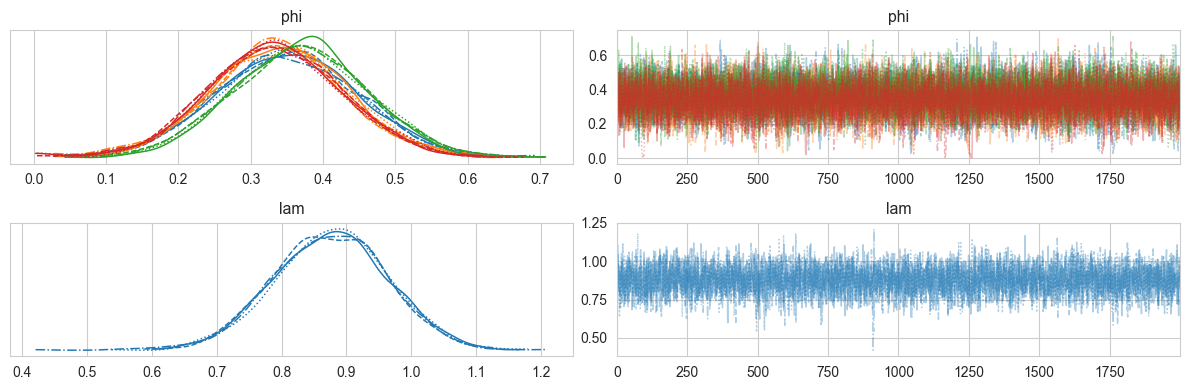

In [10]:
trace_A = None

if flat_sp is None:
    print("[skip] speaker_logit 없음")
else:
    rel_idx_sp, sta_idx_sp, utt_idx_sp, obs_sp = flat_sp

    with pm.Model() as model_A:
        phi   = pm.Uniform("phi",   lower=0, upper=1, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)
        c     = pm.Normal("c",      mu=0,    sigma=3)
        sigma = pm.HalfNormal("sigma", sigma=1)

        log_S1, _ = build_rsa(phi, lam)   # (N_rel, N_utt, N_sta)
        # log_S1은 이미 utterance 축으로 logsumexp 정규화된 log P_S1
        mu = log_S1[rel_idx_sp, utt_idx_sp, sta_idx_sp] + c

        pm.Normal("obs", mu=mu, sigma=sigma, observed=obs_sp)

    with model_A:
        trace_A = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_A, var_names=["phi", "lam", "c", "sigma"]))
    az.plot_trace(trace_A, var_names=["phi", "lam"])
    plt.tight_layout(); plt.show()

---
## Model B — Speaker Logit pRRSAf
$$\log P_{\text{LLM}}(u \mid s,r) \sim \mathcal{N}\bigl(\log P_{S1}(u \mid s,r) + c,\;\sigma\bigr)$$
$$U(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  2.284  0.660   1.153    3.575      0.013    0.010    2694.0   
alpha[1]  2.224  0.660   1.027    3.434      0.014    0.010    2675.0   
alpha[2]  2.135  0.656   0.924    3.345      0.013    0.010    3049.0   
alpha[3]  2.229  0.660   1.082    3.526      0.014    0.011    2406.0   
lam       0.276  0.053   0.175    0.374      0.001    0.001    1952.0   
c        -1.647  0.117  -1.863   -1.424      0.001    0.001    6815.0   
sigma     2.230  0.070   2.098    2.358      0.001    0.001    6715.0   

          ess_tail  r_hat  
alpha[0]    2563.0    1.0  
alpha[1]    2561.0    1.0  
alpha[2]    2580.0    1.0  
alpha[3]    2575.0    1.0  
lam         2096.0    1.0  
c           5262.0    1.0  
sigma       5265.0    1.0  


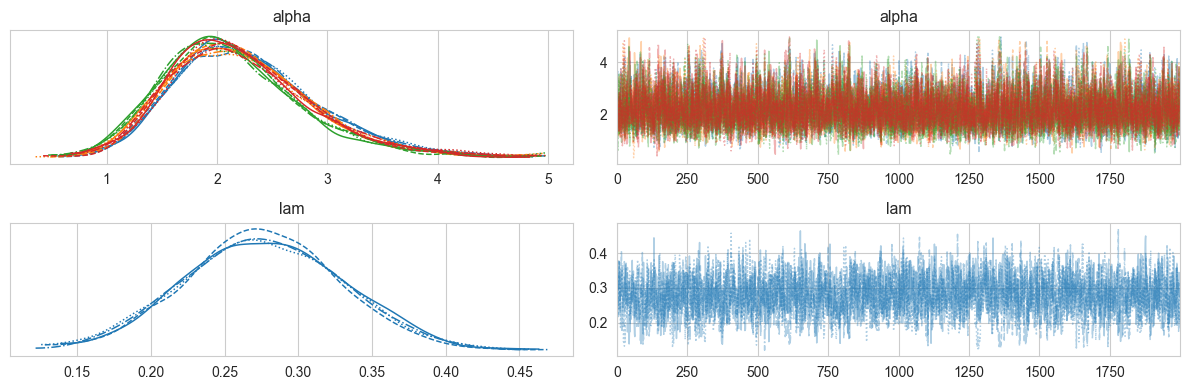

In [11]:
trace_B = None

if flat_sp is None:
    print("[skip] speaker_logit 없음")
else:
    rel_idx_sp, sta_idx_sp, utt_idx_sp, obs_sp = flat_sp

    with pm.Model() as model_B:
        alpha = pm.Uniform("alpha", lower=0, upper=5, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)
        c     = pm.Normal("c",      mu=0,    sigma=3)
        sigma = pm.HalfNormal("sigma", sigma=1)

        log_S1, _ = build_rsa_f(alpha, lam)   # (N_rel, N_utt, N_sta)
        mu = log_S1[rel_idx_sp, utt_idx_sp, sta_idx_sp] + c

        pm.Normal("obs", mu=mu, sigma=sigma, observed=obs_sp)

    with model_B:
        trace_B = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_B, var_names=["alpha", "lam", "c", "sigma"]))
    az.plot_trace(trace_B, var_names=["alpha", "lam"])
    plt.tight_layout(); plt.show()

---
## Model C — Speaker Choice (Multinomial)
$$\text{count}(u \mid s,r) \sim \text{Multinomial}(N,\; P_{S1}(u \mid s,r))$$

In [12]:
trace_C = None

if counts_speaker is None:
    print("[skip] speaker_choice 없음")
else:
    n_sp = counts_speaker.sum(axis=-1)   # (N_rel, N_sta) — 각 조건의 총 시행 수

    with pm.Model() as model_C:
        phi = pm.Uniform("phi", lower=0, upper=1, shape=N_rel)
        lam = pm.Uniform("lam", lower=0, upper=20)

        log_S1, _ = build_rsa(phi, lam)
        # log_S1[r, u, s] → transpose → [r, s, u]  (counts_speaker 축 순서)
        P_S1 = pt.exp(log_S1).transpose(0, 2, 1)   # (N_rel, N_sta, N_utt)

        pm.Multinomial("obs", n=n_sp, p=P_S1, observed=counts_speaker)

    with model_C:
        trace_C = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_C, var_names=["phi", "lam"]))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
phi[0]  0.944  0.051   0.848    1.000      0.001    0.000    5175.0    3079.0   
phi[1]  0.940  0.054   0.838    1.000      0.001    0.000    6632.0    4045.0   
phi[2]  0.893  0.086   0.736    1.000      0.001    0.001    4768.0    3242.0   
phi[3]  0.817  0.120   0.604    1.000      0.001    0.001    4926.0    2730.0   
lam     0.195  0.022   0.154    0.235      0.000    0.000    6280.0    5136.0   

        r_hat  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
lam       1.0  


---
## Model D — Speaker Choice pRRSAf (Multinomial)
$$\text{count}(u \mid s,r) \sim \text{Multinomial}(N,\; P_{S1}(u \mid s,r))$$
$$U(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

In [13]:
trace_D = None

if counts_speaker is None:
    print("[skip] speaker_choice 없음")
else:
    n_sp = counts_speaker.sum(axis=-1)   # (N_rel, N_sta)

    with pm.Model() as model_D:
        alpha = pm.Uniform("alpha", lower=0, upper=5, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)

        log_S1, _ = build_rsa_f(alpha, lam)
        P_S1 = pt.exp(log_S1).transpose(0, 2, 1)   # (N_rel, N_sta, N_utt)

        pm.Multinomial("obs", n=n_sp, p=P_S1, observed=counts_speaker)

    with model_D:
        trace_D = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_D, var_names=["alpha", "lam"]))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.124  0.113   0.000    0.327      0.001    0.001    4667.0   
alpha[1]  0.077  0.073   0.000    0.209      0.001    0.001    4325.0   
alpha[2]  0.110  0.102   0.000    0.300      0.001    0.001    3633.0   
alpha[3]  0.149  0.128   0.000    0.381      0.002    0.001    4188.0   
lam       0.173  0.021   0.135    0.212      0.000    0.000    5252.0   

          ess_tail  r_hat  
alpha[0]    2524.0    1.0  
alpha[1]    2724.0    1.0  
alpha[2]    2224.0    1.0  
alpha[3]    2766.0    1.0  
lam         4180.0    1.0  


---
## Model E — Listener Logit pRRSAc
$$\log P_{\text{LLM}}(s \mid u,r) \sim \mathcal{N}(\log P_{L1}(s \mid u,r),\; \sigma)$$

- flat 방식: 각 situation × rep × adjective × state 조합이 독립 관측치
- pytensor 인덱싱: `log_L1[r_i, u_i, s_i]` 로 μ 계산

In [14]:
trace_E = None

if flat_li is None:
    print("[skip] listener_logit 없음")
else:
    rel_idx_li, utt_idx_li, sta_idx_li, obs_li = flat_li

    with pm.Model() as model_E:
        phi   = pm.Uniform("phi",   lower=0, upper=1, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)
        c     = pm.Normal("c",      mu=0,    sigma=3)
        sigma = pm.HalfNormal("sigma", sigma=1)

        _, log_L1 = build_rsa(phi, lam)            # (N_rel, N_utt, N_sta)
        mu = log_L1[rel_idx_li, utt_idx_li, sta_idx_li] + c

        pm.Normal("obs", mu=mu, sigma=sigma, observed=obs_li)

    with model_E:
        trace_E = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_E, var_names=["phi", "lam", "c", "sigma"]))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
phi[0]  0.494  0.280   0.000    0.930      0.003    0.002    7717.0    4243.0   
phi[1]  0.478  0.279   0.002    0.931      0.003    0.002    7450.0    4564.0   
phi[2]  0.580  0.265   0.124    1.000      0.003    0.002    7343.0    4648.0   
phi[3]  0.579  0.271   0.118    1.000      0.003    0.002    8388.0    4572.0   
lam     0.150  0.069   0.028    0.270      0.001    0.001    5048.0    3359.0   
c      -0.546  0.053  -0.644   -0.447      0.001    0.000    8180.0    5849.0   
sigma   1.155  0.036   1.088    1.224      0.000    0.000    8011.0    5712.0   

        r_hat  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
lam       1.0  
c         1.0  
sigma     1.0  


---
## Model F — Listener Logit pRRSAf
$$\log P_{\text{LLM}}(s \mid u,r) \sim \mathcal{N}(\log P_{L1}(s \mid u,r),\; \sigma)$$
$$U(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

In [15]:
trace_F = None

if flat_li is None:
    print("[skip] listener_logit 없음")
else:
    rel_idx_li, utt_idx_li, sta_idx_li, obs_li = flat_li

    with pm.Model() as model_F:
        alpha = pm.Uniform("alpha", lower=0, upper=5, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)
        c     = pm.Normal("c",      mu=0,    sigma=3)
        sigma = pm.HalfNormal("sigma", sigma=1)

        _, log_L1 = build_rsa_f(alpha, lam)        # (N_rel, N_utt, N_sta)
        mu = log_L1[rel_idx_li, utt_idx_li, sta_idx_li] + c

        pm.Normal("obs", mu=mu, sigma=sigma, observed=obs_li)

    with model_F:
        trace_F = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_F, var_names=["alpha", "lam", "c", "sigma"]))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  2.204  1.442   0.000    4.594      0.016    0.013    7304.0   
alpha[1]  2.242  1.441   0.018    4.627      0.015    0.012    8822.0   
alpha[2]  2.390  1.453   0.002    4.671      0.016    0.012    7944.0   
alpha[3]  2.214  1.441   0.003    4.606      0.017    0.012    7089.0   
lam       0.065  0.029   0.011    0.116      0.000    0.000    3600.0   
c        -0.550  0.053  -0.644   -0.445      0.001    0.000    8099.0   
sigma     1.156  0.036   1.089    1.222      0.000    0.000    7881.0   

          ess_tail  r_hat  
alpha[0]    4026.0    1.0  
alpha[1]    5041.0    1.0  
alpha[2]    4819.0    1.0  
alpha[3]    4434.0    1.0  
lam         2036.0    1.0  
c           5370.0    1.0  
sigma       5134.0    1.0  


---
## Model H — Listener Choice pRRSAf (Multinomial)
$$\text{count}(s \mid u,r) \sim \text{Multinomial}(N,\; P_{L1}(s \mid u,r))$$
$$U(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

In [16]:
trace_H = None

if counts_listener is None:
    print("[skip] listener_choice 없음")
else:
    n_li = counts_listener.sum(axis=-1)   # (N_rel, N_utt)

    with pm.Model() as model_H:
        alpha = pm.Uniform("alpha", lower=0, upper=5, shape=N_rel)
        lam   = pm.Uniform("lam",   lower=0, upper=20)

        _, log_L1 = build_rsa_f(alpha, lam)
        P_L1 = pt.exp(log_L1)

        pm.Multinomial("obs", n=n_li, p=P_L1, observed=counts_listener)

    with model_H:
        trace_H = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_H, var_names=["alpha", "lam"]))

[skip] listener_choice 없음


In [17]:
# ── 파라미터 수렴 진단 ─────────────────────────────────────────────────────────
TRACES = {
    "A: Speaker Logit   pRRSAc": (trace_A, "phi"),
    "B: Speaker Logit   pRRSAf": (trace_B, "alpha"),
    "C: Speaker Choice  pRRSAc": (trace_C, "phi"),
    "D: Speaker Choice  pRRSAf": (trace_D, "alpha"),
    "E: Listener Logit  pRRSAc": (trace_E, "phi"),
    "F: Listener Logit  pRRSAf": (trace_F, "alpha"),
    "G: Listener Choice pRRSAc": (trace_G, "phi"),
    "H: Listener Choice pRRSAf": (trace_H, "alpha"),
}
for name, (trace, pname) in TRACES.items():
    if trace is None:
        print(f"  {name:<32} [skip]")
        continue
    rhat_vals = [float(az.rhat(trace)[v].values.max())
                 for v in [pname, "lam"] if v in trace.posterior]
    max_r = max(rhat_vals) if rhat_vals else float("nan")
    status = "✓" if max_r < 1.01 else "△" if max_r < 1.05 else "✗"
    print(f"{status} {name:<32} max R-hat = {max_r:.4f}")

NameError: name 'trace_G' is not defined

In [ ]:
# ── φ 비교 (pRRSAc 모델 A/C/E/G) vs 인간 ─────────────────────────────────────
phi_traces = {k: v for k, v in
              {"A": trace_A, "C": trace_C, "E": trace_E, "G": trace_G}.items()
              if v is not None and "phi" in v.posterior}

# ── α 비교 (pRRSAf 모델 B/D/F/H) vs 인간 ─────────────────────────────────────
alpha_traces = {k: v for k, v in
                {"B": trace_B, "D": trace_D, "F": trace_F, "H": trace_H}.items()
                if v is not None and "alpha" in v.posterior}

n_plots = (1 if phi_traces else 0) + (1 if alpha_traces else 0)
if n_plots == 0:
    print("[skip] 아직 완료된 모델 없음")
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    ax_idx = 0
    labels = [r.replace(" ", "\n") for r in RELATIONS]
    x = np.arange(N_rel)
    width = 0.15

    # ── φ subplot ──────────────────────────────────────────────────────────
    if phi_traces:
        ax = axes[ax_idx]; ax_idx += 1
        colors = {"A": "#3498db", "C": "#2ecc71", "E": "#e74c3c", "G": "#9b59b6"}
        offsets = np.linspace(-len(phi_traces)*width/2, len(phi_traces)*width/2,
                              len(phi_traces)+2)[1:-1]
        for i, (key, trace) in enumerate(phi_traces.items()):
            samples = trace.posterior["phi"].values
            mean = samples.mean(axis=(0, 1))
            std  = samples.std(axis=(0, 1))
            ax.bar(x + offsets[i], mean, width, label=f"LLM Model {key}",
                   color=colors[key], alpha=0.8)
            ax.errorbar(x + offsets[i], mean, std, fmt="none",
                        color="black", capsize=3, linewidth=1)
        ax.plot(x, [HUMAN_PHI[r] for r in RELATIONS], "k--o",
                linewidth=2, markersize=7, label="Human (Lumer Table 4)")
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel("φ  (epistemic weight)", fontsize=12)
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.legend(fontsize=9); ax.set_title("pRRSAc — φ per relationship")

    # ── α subplot ──────────────────────────────────────────────────────────
    if alpha_traces:
        ax = axes[ax_idx]
        colors = {"B": "#e67e22", "D": "#1abc9c", "F": "#e74c3c", "H": "#34495e"}
        offsets = np.linspace(-len(alpha_traces)*width/2, len(alpha_traces)*width/2,
                              len(alpha_traces)+2)[1:-1]
        for i, (key, trace) in enumerate(alpha_traces.items()):
            samples = trace.posterior["alpha"].values
            mean = samples.mean(axis=(0, 1))
            std  = samples.std(axis=(0, 1))
            ax.bar(x + offsets[i], mean, width, label=f"LLM Model {key}",
                   color=colors[key], alpha=0.8)
            ax.errorbar(x + offsets[i], mean, std, fmt="none",
                        color="black", capsize=3, linewidth=1)
        ax.plot(x, [HUMAN_ALPHA[r] for r in RELATIONS], "k--o",
                linewidth=2, markersize=7, label="Human (Lumer Table 4)")
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel("α  (social utility weight)", fontsize=12)
        ax.set_ylim(0, 6)
        ax.legend(fontsize=9); ax.set_title("pRRSAf — α per relationship")

    fig.suptitle(f"파라미터 비교 — {MODEL} vs Human (Lumer)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"results/plot_params_{MODEL}.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## Step 6 — 인간 레퍼런스 (Lumer et al.)

논문 Table 3, 4 수치 — LLM 추정값과 비교 기준

In [ ]:
# ── Table 4 — pRRSAc MAP 추정값 ───────────────────────────────────────────────
HUMAN_LAM = 4.59
HUMAN_PHI = {   # φ: face-saving 비중 (높을수록 polite)
    "Enge Freundin":      0.45,
    "Entfernte Kollegin": 0.31,
    "Lockere Chefin":     0.37,
    "Gefürchtete Chefin": 0.22,
}

# ── Table 4 — pRRSAf MAP 추정값 ───────────────────────────────────────────────
HUMAN_LAM_F = 2.25
HUMAN_ALPHA = {  # α: social utility 가중치 (높을수록 face-saving)
    "Enge Freundin":      1.88,
    "Entfernte Kollegin": 2.90,
    "Lockere Chefin":     1.97,
    "Gefürchtete Chefin": 4.63,
}

# ── Table 3 — 인간 화자 실험 평균 state (Exp. 3) ──────────────────────────────
HUMAN_TABLE3 = {
    ("Enge Freundin",      "großartig"):    4.80,
    ("Enge Freundin",      "gut"):          3.31,
    ("Enge Freundin",      "okay"):         2.38,
    ("Enge Freundin",      "schlecht"):     1.12,
    ("Enge Freundin",      "schrecklich"):  1.18,
    ("Entfernte Kollegin", "großartig"):    4.31,
    ("Entfernte Kollegin", "gut"):          2.91,
    ("Entfernte Kollegin", "okay"):         2.04,
    ("Entfernte Kollegin", "schlecht"):     1.26,
    ("Entfernte Kollegin", "schrecklich"):  1.04,
    ("Lockere Chefin",     "großartig"):    4.46,
    ("Lockere Chefin",     "gut"):          3.27,
    ("Lockere Chefin",     "okay"):         2.30,
    ("Lockere Chefin",     "schlecht"):     1.25,
    ("Lockere Chefin",     "schrecklich"):  1.07,
    ("Gefürchtete Chefin", "großartig"):    3.69,
    ("Gefürchtete Chefin", "gut"):          2.59,
    ("Gefürchtete Chefin", "okay"):         1.67,
    ("Gefürchtete Chefin", "schlecht"):     1.19,
    ("Gefürchtete Chefin", "schrecklich"):  1.11,
}

# ── Table 5 — 논문 R² per relationship ────────────────────────────────────────
HUMAN_R2 = {
    "Enge Freundin":       0.79,
    "Entfernte Kollegin":  0.78,
    "Lockere Chefin":      0.74,
    "Gefürchtete Chefin": -0.20,
}

print("인간 레퍼런스 로드 완료")
print(f"  λ: pRRSAc={HUMAN_LAM}  pRRSAf={HUMAN_LAM_F}")
print(f"  {'':22s}  {'φ (pRRSAc)':>10}  {'α (pRRSAf)':>10}")
for rel in RELATIONS:
    print(f"  {rel:22s}  {HUMAN_PHI[rel]:10.2f}  {HUMAN_ALPHA[rel]:10.2f}")

---
## Step 7 — 결과 비교

In [ ]:
# ── Predicted Mean State: E[s | u, r] ────────────────────────────────────────
# RSA 화자 분포에서 어떤 발화 u를 골랐을 때 역추론되는 기대 state
# (= Lumer Table 3 비교 기준)

def pred_mean_state(phi_dict, lam):
    """관계별·발화별 E[s | u, r] 계산 (numpy RSA 사용)"""
    rows = []
    for rel in RELATIONS:
        phi = phi_dict[rel]
        # S1 행렬: (N_sta, N_utt)
        S1 = np.stack([rsa_speaker(s_i, phi=phi, lam=lam) for s_i in range(N_sta)])
        for u_i, utt in enumerate(UTTERANCES):
            s_probs = S1[:, u_i]           # P(u|s) for all s
            denom   = s_probs.sum()
            e_s     = (np.array(STATES, float) * s_probs).sum() / denom if denom > 0 else np.nan
            rows.append({"relationship": rel, "utterance": utt, "pred_mean": e_s})
    return pd.DataFrame(rows)

# 각 소스별 계산
results_dfs = {}

if trace_A is not None:
    summ = az.summary(trace_A, var_names=["phi", "lam"])
    phi_llm  = {rel: summ.loc[f"phi[{i}]", "mean"] for i, rel in enumerate(RELATIONS)}
    lam_llm  = summ.loc["lam", "mean"]
    results_dfs[f"LLM_A ({MODEL})"] = pred_mean_state(phi_llm, lam_llm)

results_dfs["Human MAP"] = pred_mean_state(HUMAN_PHI, HUMAN_LAM)
human_exp_rows = [{"relationship": r, "utterance": u, "pred_mean": v}
                  for (r, u), v in HUMAN_TABLE3.items()]
results_dfs["Human Exp"] = pd.DataFrame(human_exp_rows)

palette  = {f"LLM_A ({MODEL})": "#3498db", "Human MAP": "#e67e22", "Human Exp": "#27ae60"}
linestyl = {f"LLM_A ({MODEL})": "-",  "Human MAP": "--", "Human Exp": ":"}
markers  = {f"LLM_A ({MODEL})": "o",  "Human MAP": "s",  "Human Exp": "^"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, rel in zip(axes.flatten(), RELATIONS):
    for src, df_src in results_dfs.items():
        sub = (df_src[df_src["relationship"] == rel]
               .set_index("utterance").reindex(UTTERANCES)["pred_mean"])
        ax.plot(UTTERANCES, sub.values, marker=markers[src],
                label=src, color=palette[src],
                linestyle=linestyl[src], linewidth=2, markersize=7)
    ax.set_title(rel, fontweight="bold")
    ax.set_ylim(1, 5.3); ax.set_ylabel("E[state | u]")
    ax.set_xticklabels(UTTERANCES, rotation=25, ha="right", fontsize=9)
    ax.axhline(3, color="gray", linestyle=":", alpha=0.3)
axes[0, 0].legend(fontsize=9)
fig.suptitle("Predicted Mean State — LLM vs Human", fontsize=13)
plt.tight_layout()
plt.savefig(f"results/plot_pred_mean_state_{MODEL}.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── R² 비교: 각 모델 예측 vs Human Exp (Table 3) ──────────────────────────────
def r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0

print(f"{'Relationship':22s}  ", end="")
for src in results_dfs: print(f"{src:>14}", end="")
print(f"  {'Human(논문)':>10}")
print("-" * (24 + 14 * len(results_dfs) + 12))

for rel in RELATIONS:
    human_exp = np.array([HUMAN_TABLE3.get((rel, u), np.nan) for u in UTTERANCES])
    print(f"  {rel:22s}", end="")
    for src, df_src in results_dfs.items():
        pred = (df_src[df_src["relationship"] == rel]
                .set_index("utterance").reindex(UTTERANCES)["pred_mean"].values)
        mask = ~np.isnan(human_exp) & ~np.isnan(pred)
        print(f"  {r2(human_exp[mask], pred[mask]):12.3f}", end="")
    print(f"  {HUMAN_R2.get(rel, float('nan')):10.3f}")
print("\n참고: Human(논문) = pRRSAc with Lumer Values parameters (Table 5)")

In [ ]:
# ── Posterior Predictive Check ────────────────────────────────────────────────
if trace_A is None or logprobs_speaker is None:
    print("[skip] Model A trace 또는 speaker_logit 없음")
else:
    posterior = trace_A.posterior
    lam_s = posterior["lam"].values.flatten()
    phi_s = posterior["phi"].values.reshape(-1, N_rel)
    n_samp = len(lam_s)

    ppc_rows = []
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES):
            probs_obs = np.exp(logprobs_speaker[r_i, s_i, :])   # (N_utt,)
            for u_i, utt in enumerate(UTTERANCES):
                preds = np.array([rsa_speaker(s_i, phi=phi_s[j, r_i], lam=lam_s[j])[u_i]
                                  for j in range(n_samp)])
                ppc_rows.append({
                    "relationship": rel, "state": sta, "utterance": utt,
                    "prob_obs"   : probs_obs[u_i],
                    "pred_mean"  : preds.mean(),
                    "pred_lo"    : np.percentile(preds, 3),
                    "pred_hi"    : np.percentile(preds, 97),
                })

    df_ppc = pd.DataFrame(ppc_rows)
    rel_colors = dict(zip(RELATIONS, ["#e74c3c", "#3498db", "#2ecc71", "#e67e22"]))
    rel_markers = dict(zip(RELATIONS, ["o", "s", "^", "D"]))

    fig, ax = plt.subplots(figsize=(6, 6))
    for rel in RELATIONS:
        d = df_ppc[df_ppc["relationship"] == rel]
        ax.errorbar(d["pred_mean"], d["prob_obs"],
                    xerr=[d["pred_mean"] - d["pred_lo"], d["pred_hi"] - d["pred_mean"]],
                    fmt=rel_markers[rel], color=rel_colors[rel],
                    label=rel.replace(" ", "\n"), alpha=0.65,
                    markersize=5, capsize=2, linewidth=0.8)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("RSA posterior predictive P(u|s,r)")
    ax.set_ylabel("LLM observed P(u|s,r)")
    r_ppc = np.corrcoef(df_ppc["pred_mean"], df_ppc["prob_obs"])[0, 1]
    ax.set_title(f"Posterior Predictive Check — Model A  r={r_ppc:.3f}")
    ax.legend(fontsize=8, title="Relationship")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig(f"results/plot_ppc_{MODEL}.png", dpi=150)
    plt.show()
    print(f"Pearson r = {r_ppc:.3f}  ({len(df_ppc)} 조합)")